# Analisis descriptivo — Telemetria de GPU (detector de fallas)




In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv("../data/telemetria_publica.csv")
print(df.shape)
df.head()


(14400, 8)


,episodio_id,segundo,temp_c,power_w,util_pct,clock_mhz,ecc_errors,estado
0,0,0,56.2,234.5,76.2,2412.0,0,normal
1,0,1,50.8,169.3,63.1,2403.0,0,normal
2,0,2,58.0,217.3,85.3,2396.0,0,normal
3,0,3,58.8,193.4,62.5,2448.0,0,normal
4,0,4,47.2,198.8,62.4,2381.0,0,normal


## 1. Vista general del dataset

In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   episodio_id  14400 non-null  int64  
 1   segundo      14400 non-null  int64  
 2   temp_c       14400 non-null  float64
 3   power_w      14400 non-null  float64
 4   util_pct     14400 non-null  float64
 5   clock_mhz    14400 non-null  float64
 6   ecc_errors   14400 non-null  int64  
 7   estado       14400 non-null  str    
dtypes: float64(4), int64(3), str(1)
memory usage: 900.1 KB


In [16]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
episodio_id,14400.0,23.500000,13.853880,0.0,11.75,23.50,35.250,47.0
segundo,14400.0,149.500000,86.605066,0.0,74.75,149.50,224.250,299.0
temp_c,14400.0,63.238500,15.685635,22.1,52.80,58.10,77.825,99.2
power_w,14400.0,210.017167,60.317757,-18.1,176.20,206.25,268.125,335.2
util_pct,14400.0,71.730639,21.096286,0.0,58.80,72.90,91.100,100.0
clock_mhz,14400.0,2169.216875,269.513699,1022.0,2015.00,2291.00,2392.000,2546.0
ecc_errors,14400.0,1.335000,2.424869,0.0,0.00,0.00,1.000,14.0


In [17]:
print("Filas:", len(df))
print("Episodios unicos:", df['episodio_id'].nunique())
print("Segundos por episodio")
print(df.groupby('episodio_id').size().describe())
print("\nValores nulos por columna:")
print(df.isna().sum())


Filas: 14400
Episodios unicos: 48
Segundos por episodio
count     48.0
mean     300.0
std        0.0
min      300.0
25%      300.0
50%      300.0
75%      300.0
max      300.0
dtype: float64

Valores nulos por columna:
episodio_id    0
segundo        0
temp_c         0
power_w        0
util_pct       0
clock_mhz      0
ecc_errors     0
estado         0
dtype: int64


## 2. Calidad de datos

Antes de confiar en el dataset, buscamos valores fuera de rango fisico:
temperaturas imposibles, potencia negativa, utilizacion fuera de [0,100],
ecc_errors negativos, o estados invalidos. Esto es justo lo que valida
`src/schema.py` (pandera) antes de entrenar.



In [18]:
anomalias = {
    "temp_c fuera de [0, 120]": ((df.temp_c < 0) | (df.temp_c > 120)).sum(),
    "power_w <= 0": (df.power_w <= 0).sum(),
    "util_pct fuera de [0, 100]": ((df.util_pct < 0) | (df.util_pct > 100)).sum(),
    "clock_mhz <= 0": (df.clock_mhz <= 0).sum(),
    "ecc_errors < 0": (df.ecc_errors < 0).sum(),
    "estado invalido": (~df.estado.isin(
        ["normal", "sobrecalentamiento", "degradacion_memoria", "falla_alimentacion"]
    )).sum(),
}
pd.Series(anomalias, name="filas_invalidas").to_frame()


,filas_invalidas
"temp_c fuera de [0, 120]",0
power_w <= 0,3
"util_pct fuera de [0, 100]",0
clock_mhz <= 0,0
ecc_errors < 0,0
estado invalido,0


In [19]:
# Las filas con power_w <= 0 en detalle
df[df.power_w <= 0]


,episodio_id,segundo,temp_c,power_w,util_pct,clock_mhz,ecc_errors,estado
10907,36,107,56.7,-13.5,47.8,2020.0,0,falla_alimentacion
11662,38,262,50.1,-3.9,27.7,1844.0,0,falla_alimentacion
13358,44,158,55.3,-18.1,36.1,1714.0,0,falla_alimentacion


**Hallazgo:** hay filas con `power_w` negativo (ruido de sensor), todas
dentro de episodios `falla_alimentacion` — tiene sentido: esa es justamente
la clase con lecturas de potencia inestables. El contrato de datos las
descarta antes de entrenar.


## 3. Balance de clases

In [20]:
orden_estados = ["normal", "sobrecalentamiento", "degradacion_memoria", "falla_alimentacion"]

conteo_filas = df["estado"].value_counts().reindex(orden_estados)
conteo_episodios = df.groupby("estado")["episodio_id"].nunique().reindex(orden_estados)

resumen = pd.DataFrame({"filas": conteo_filas, "episodios": conteo_episodios})
resumen


,filas,episodios
estado,,
normal,3600,12
sobrecalentamiento,3600,12
degradacion_memoria,3600,12
falla_alimentacion,3600,12


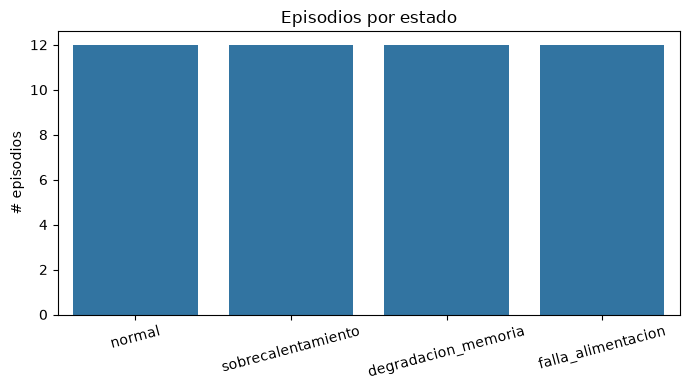

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=conteo_episodios.index, y=conteo_episodios.values, ax=ax)
ax.set_title("Episodios por estado")
ax.set_ylabel("# episodios")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


 el dataset esta perfectamente balanceado (12 episodios / 3600 filas por clase), asi que la accuracy simple es una metrica confiable 

## 4. Estadisticas por estado

In [22]:
señales = ["temp_c", "power_w", "util_pct", "clock_mhz", "ecc_errors"]

tabla = df.groupby("estado")[señales].agg(["mean", "std"]).reindex(orden_estados)
tabla.round(2)


temp_c       power_w        util_pct        clock_mhz  \
                      mean   std    mean    std     mean    std      mean   
estado                                                                      
normal               54.91  4.01  200.14  20.04    69.77  12.04   2400.66   
sobrecalentamiento   88.04  2.98  290.32  10.10    94.89   3.66   2098.59   
degradacion_memoria  60.01  5.02  209.14  25.11    67.81  13.86   2378.92   
falla_alimentacion   50.00  7.99  140.47  45.10    54.45  23.99   1798.70   

                            ecc_errors        
                        std       mean   std  
estado                                        
normal                29.70       0.02  0.16  
sobrecalentamiento    80.41       0.10  0.31  
degradacion_memoria   39.84       5.01  2.27  
falla_alimentacion   204.44       0.20  0.46

**Lectura rapida:**
- `sobrecalentamiento`: temperatura y potencia muy por encima del resto, clock por debajo de lo normal (throttling).
- `degradacion_memoria`: `ecc_errors` muchisimo mas alto que las demas clases — la señal mas clara de esta falla.
- `falla_alimentacion`: la mayor desviacion estandar en `power_w` y `clock_mhz` — inestabilidad, no un nivel distinto.
- `normal`: todo dentro de rangos moderados y estables.


## 5. Distribuciones por señal y por estado

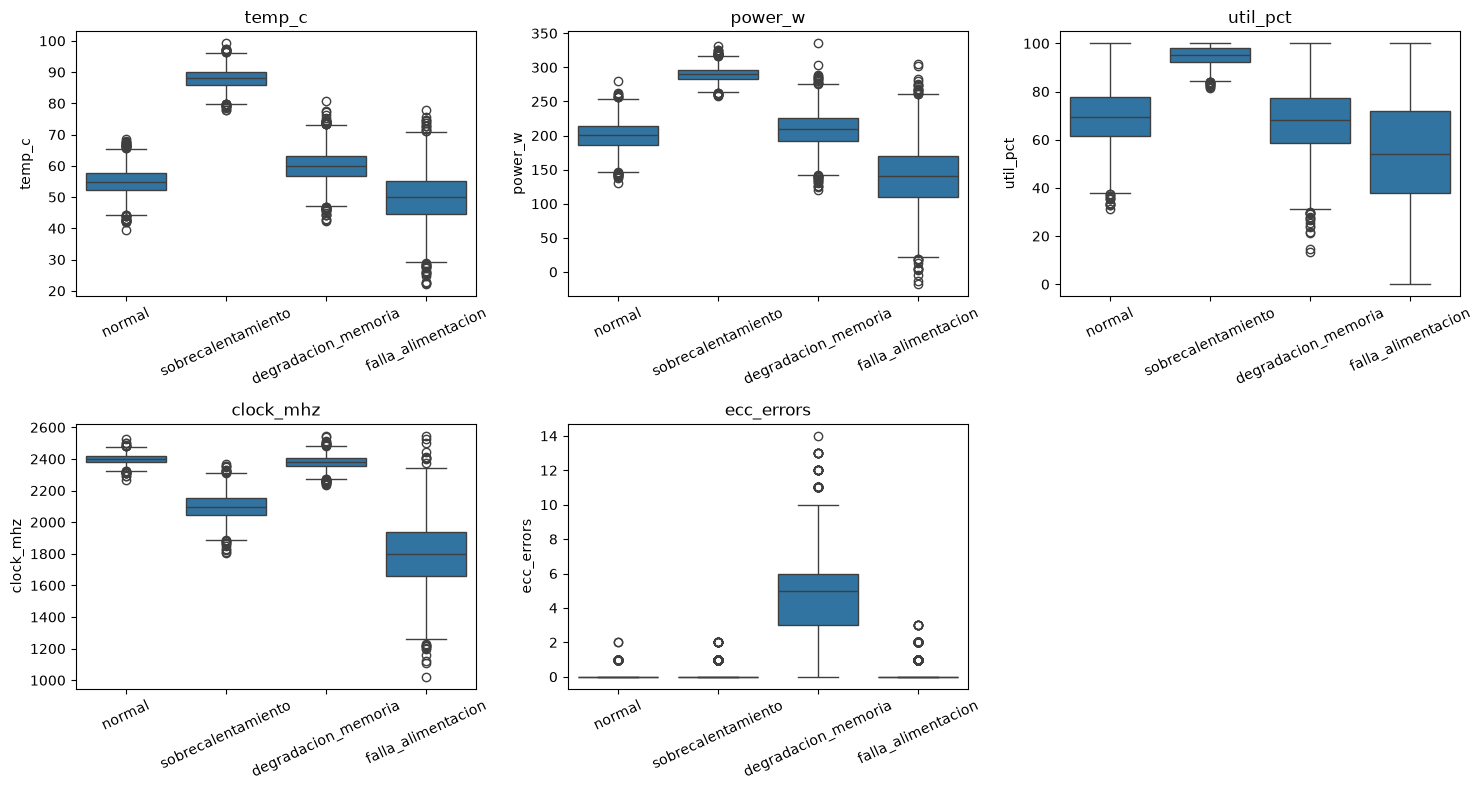

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, s in enumerate(señales):
    sns.boxplot(data=df, x="estado", y=s, order=orden_estados, ax=axes[i])
    axes[i].set_title(s)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


Los boxplots confirman lo que mostraba la tabla: `temp_c` y `power_w` separan muy bien a `sobrecalentamiento`; `ecc_errors` separa a `degradacion_memoria`; `power_w` y `clock_mhz` muestran colas/dispersion mucho mas anchas en `falla_alimentacion`.

## 6. ECC errors: la señal mas discreta

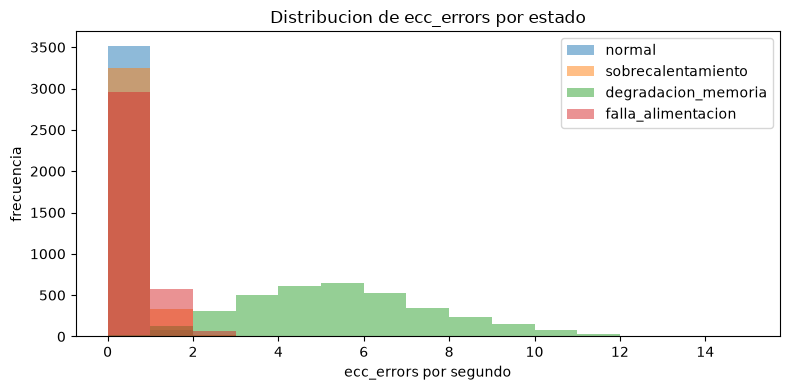

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
for estado in orden_estados:
    sub = df[df.estado == estado]["ecc_errors"]
    ax.hist(sub, bins=range(0, int(df.ecc_errors.max()) + 2), alpha=0.5, label=estado)
ax.set_xlabel("ecc_errors por segundo")
ax.set_ylabel("frecuencia")
ax.set_title("Distribucion de ecc_errors por estado")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Series de tiempo: un episodio de ejemplo por estado

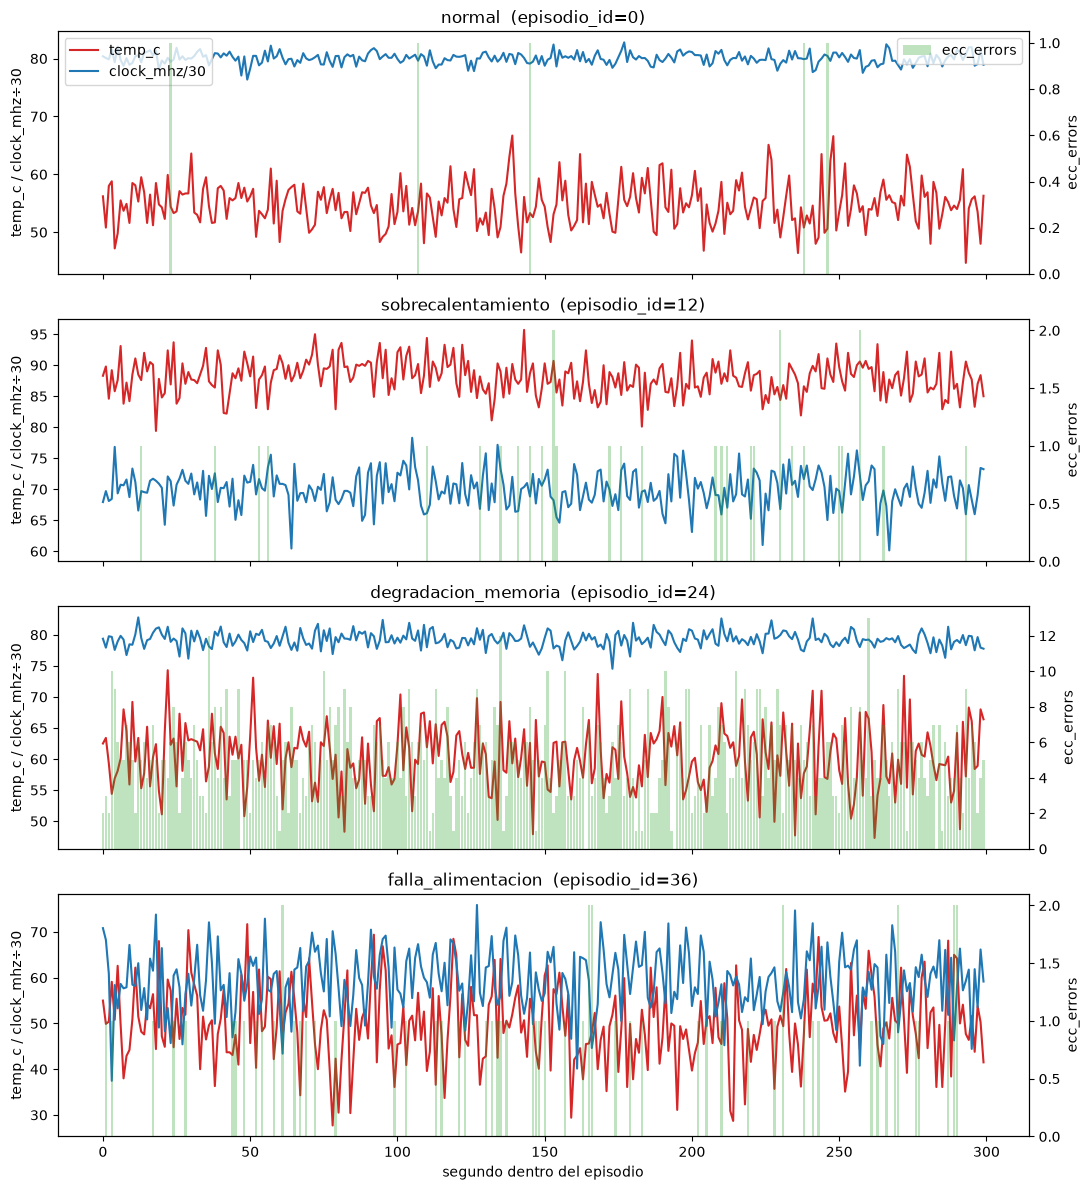

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

for ax, estado in zip(axes, orden_estados):
    episodio_ejemplo = df[df.estado == estado]["episodio_id"].iloc[0]
    ep = df[df.episodio_id == episodio_ejemplo].sort_values("segundo")

    ax2 = ax.twinx()
    ax.plot(ep["segundo"], ep["temp_c"], color="tab:red", label="temp_c")
    ax.plot(ep["segundo"], ep["clock_mhz"] / 30, color="tab:blue", label="clock_mhz/30")
    ax2.bar(ep["segundo"], ep["ecc_errors"], color="tab:green", alpha=0.3, label="ecc_errors")

    ax.set_title(f"{estado}  (episodio_id={episodio_ejemplo})")
    ax.set_ylabel("temp_c / clock_mhz÷30")
    ax2.set_ylabel("ecc_errors")
    if estado == orden_estados[0]:
        ax.legend(loc="upper left")
        ax2.legend(loc="upper right")

axes[-1].set_xlabel("segundo dentro del episodio")
plt.tight_layout()
plt.show()


Un episodio real de cada clase, segundo a segundo. Se ve a simple vista el nivel alto y estable de `sobrecalentamiento`, los picos de ECC en `degradacion_memoria`, y el ruido/inestabilidad en `falla_alimentacion` frente al comportamiento plano de `normal`.

## 8. Correlacion entre señales

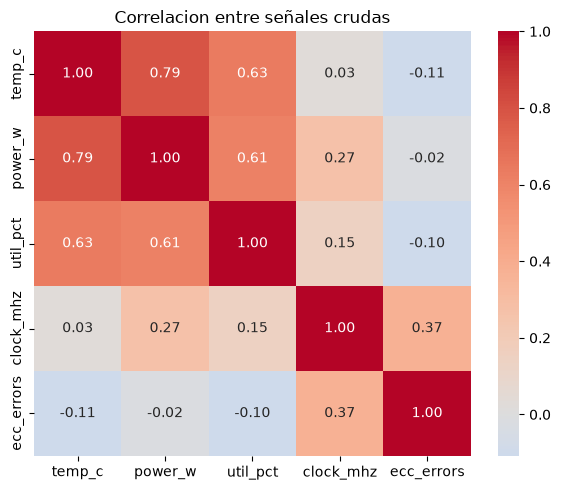

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[señales].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlacion entre señales crudas")
plt.tight_layout()
plt.show()


`temp_c` y `power_w` estan correlacionadas positivamente (mas potencia, mas calor, es fisicamente esperable); `clock_mhz` cae cuando sube la temperatura, consistente con throttling termico.